In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries imported successfully')

Libraries imported successfully


In [17]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
print('Dataset Info')
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
print('Statistical Summary')
df.describe()

Statistical Summary


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
print('Missing Values')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

Missing Values


,Missing Count,Missing %
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


## 🧹 Step 4: Data Cleaning

In [21]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed: {before - after}')
print(f'Remaining missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print('Data cleaned successfully')

Duplicates removed: 0
Remaining missing values:
Series([], dtype: int64)
Data cleaned successfully


In [22]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100], labels=['Child','Teen','Young Adult','Adult','Senior'])

print('Feature engineering done')
df[['Name','Title','FamilySize','IsAlone','AgeGroup']].head()

Feature engineering done


,Name,Title,FamilySize,IsAlone,AgeGroup
0,"Braund, Mr. Owen Harris",Mr,2,0,Young Adult
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,Adult
2,"Heikkinen, Miss. Laina",Miss,1,1,Young Adult
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,Young Adult
4,"Allen, Mr. William Henry",Mr,1,1,Young Adult


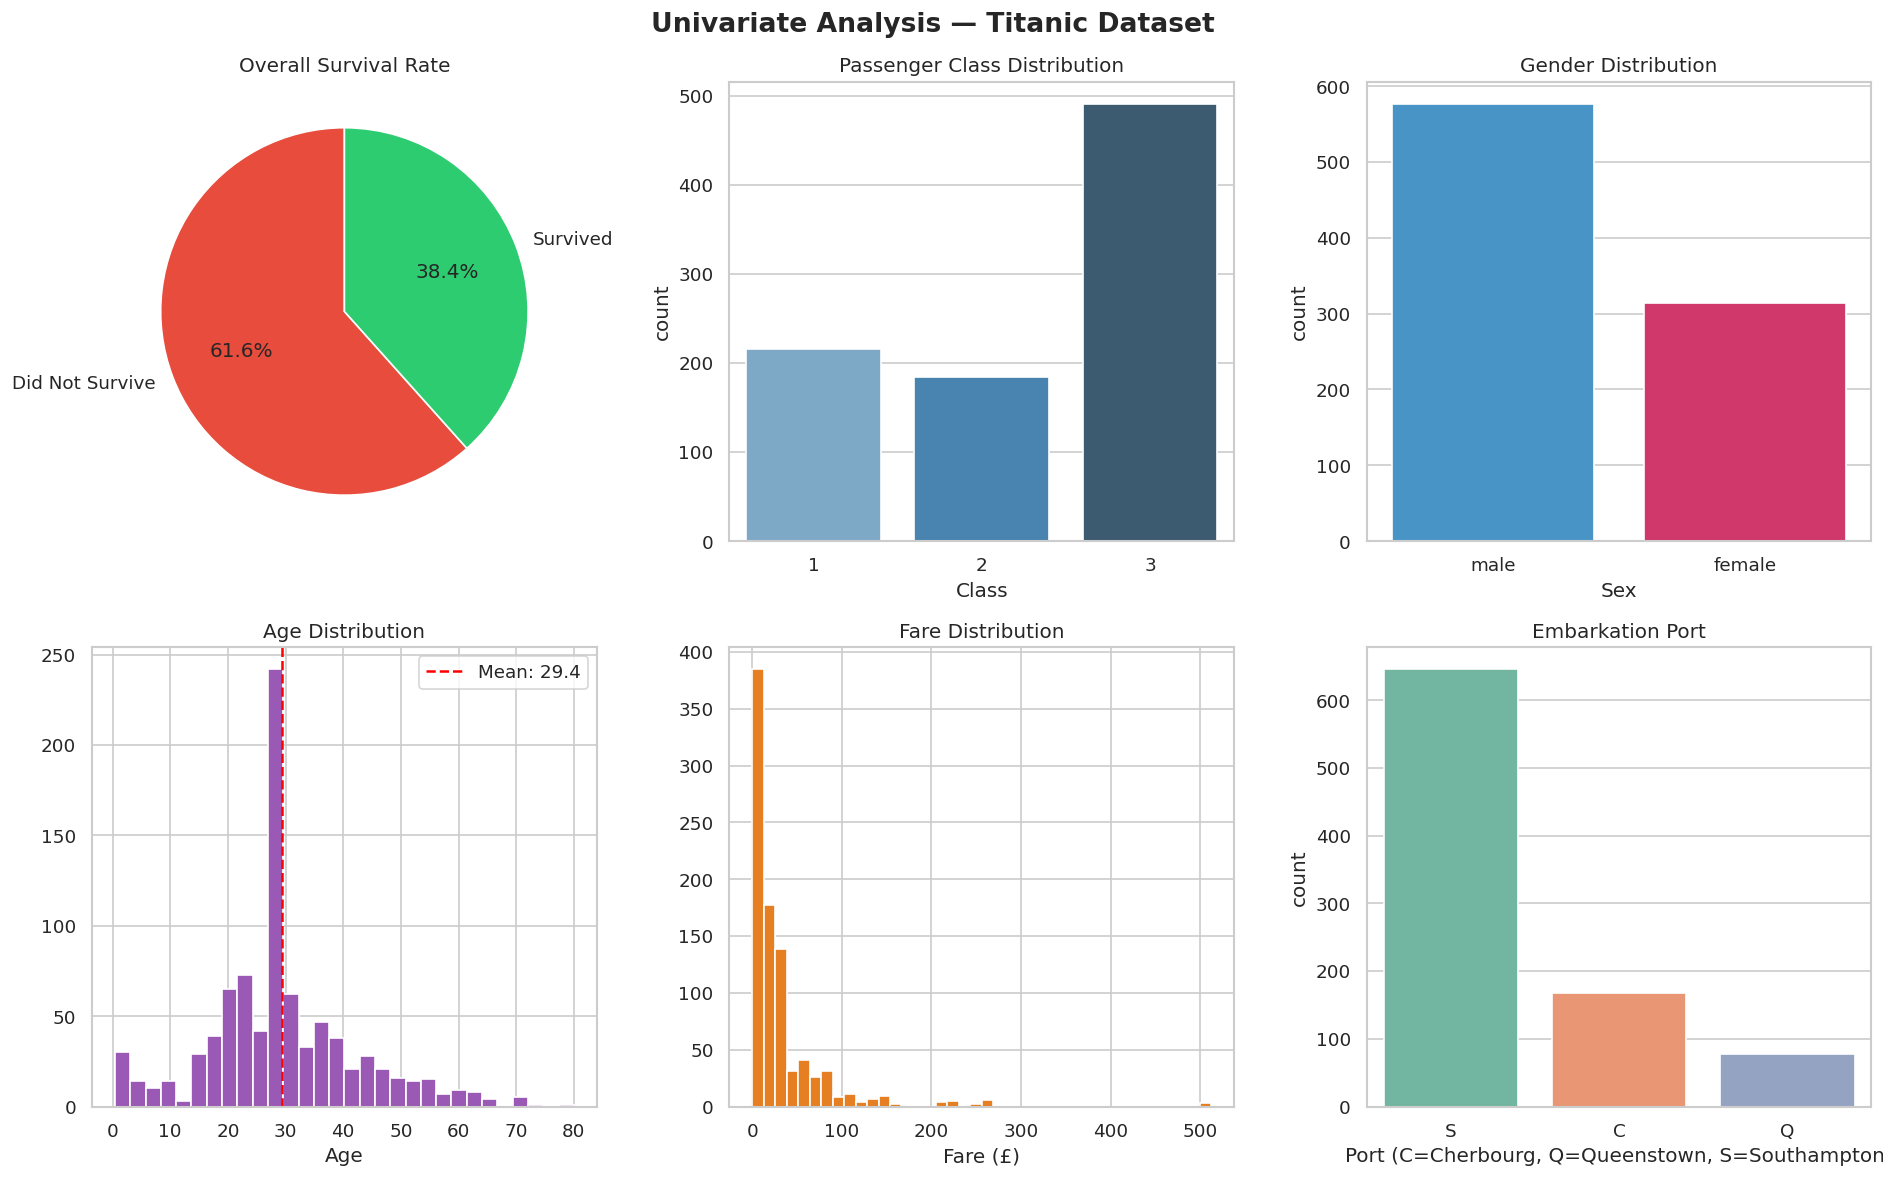

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Univariate Analysis — Titanic Dataset', fontsize=16, fontweight='bold')

survival_counts = df['Survived'].value_counts()
axes[0,0].pie(survival_counts, labels=['Did Not Survive','Survived'], autopct='%1.1f%%',
              colors=['#e74c3c','#2ecc71'], startangle=90)
axes[0,0].set_title('Overall Survival Rate')

sns.countplot(x='Pclass', data=df, ax=axes[0,1], palette='Blues_d')
axes[0,1].set_title('Passenger Class Distribution')
axes[0,1].set_xlabel('Class')

sns.countplot(x='Sex', data=df, ax=axes[0,2], palette=['#3498db','#e91e63'])
axes[0,2].set_title('Gender Distribution')

axes[1,0].hist(df['Age'], bins=30, color='#9b59b6', edgecolor='white')
axes[1,0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

axes[1,1].hist(df['Fare'], bins=40, color='#e67e22', edgecolor='white')
axes[1,1].set_title('Fare Distribution')
axes[1,1].set_xlabel('Fare (£)')

sns.countplot(x='Embarked', data=df, ax=axes[1,2], palette='Set2')
axes[1,2].set_title('Embarkation Port')
axes[1,2].set_xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')

plt.tight_layout()
plt.savefig('univariate_analysis.png', bbox_inches='tight')
plt.show()

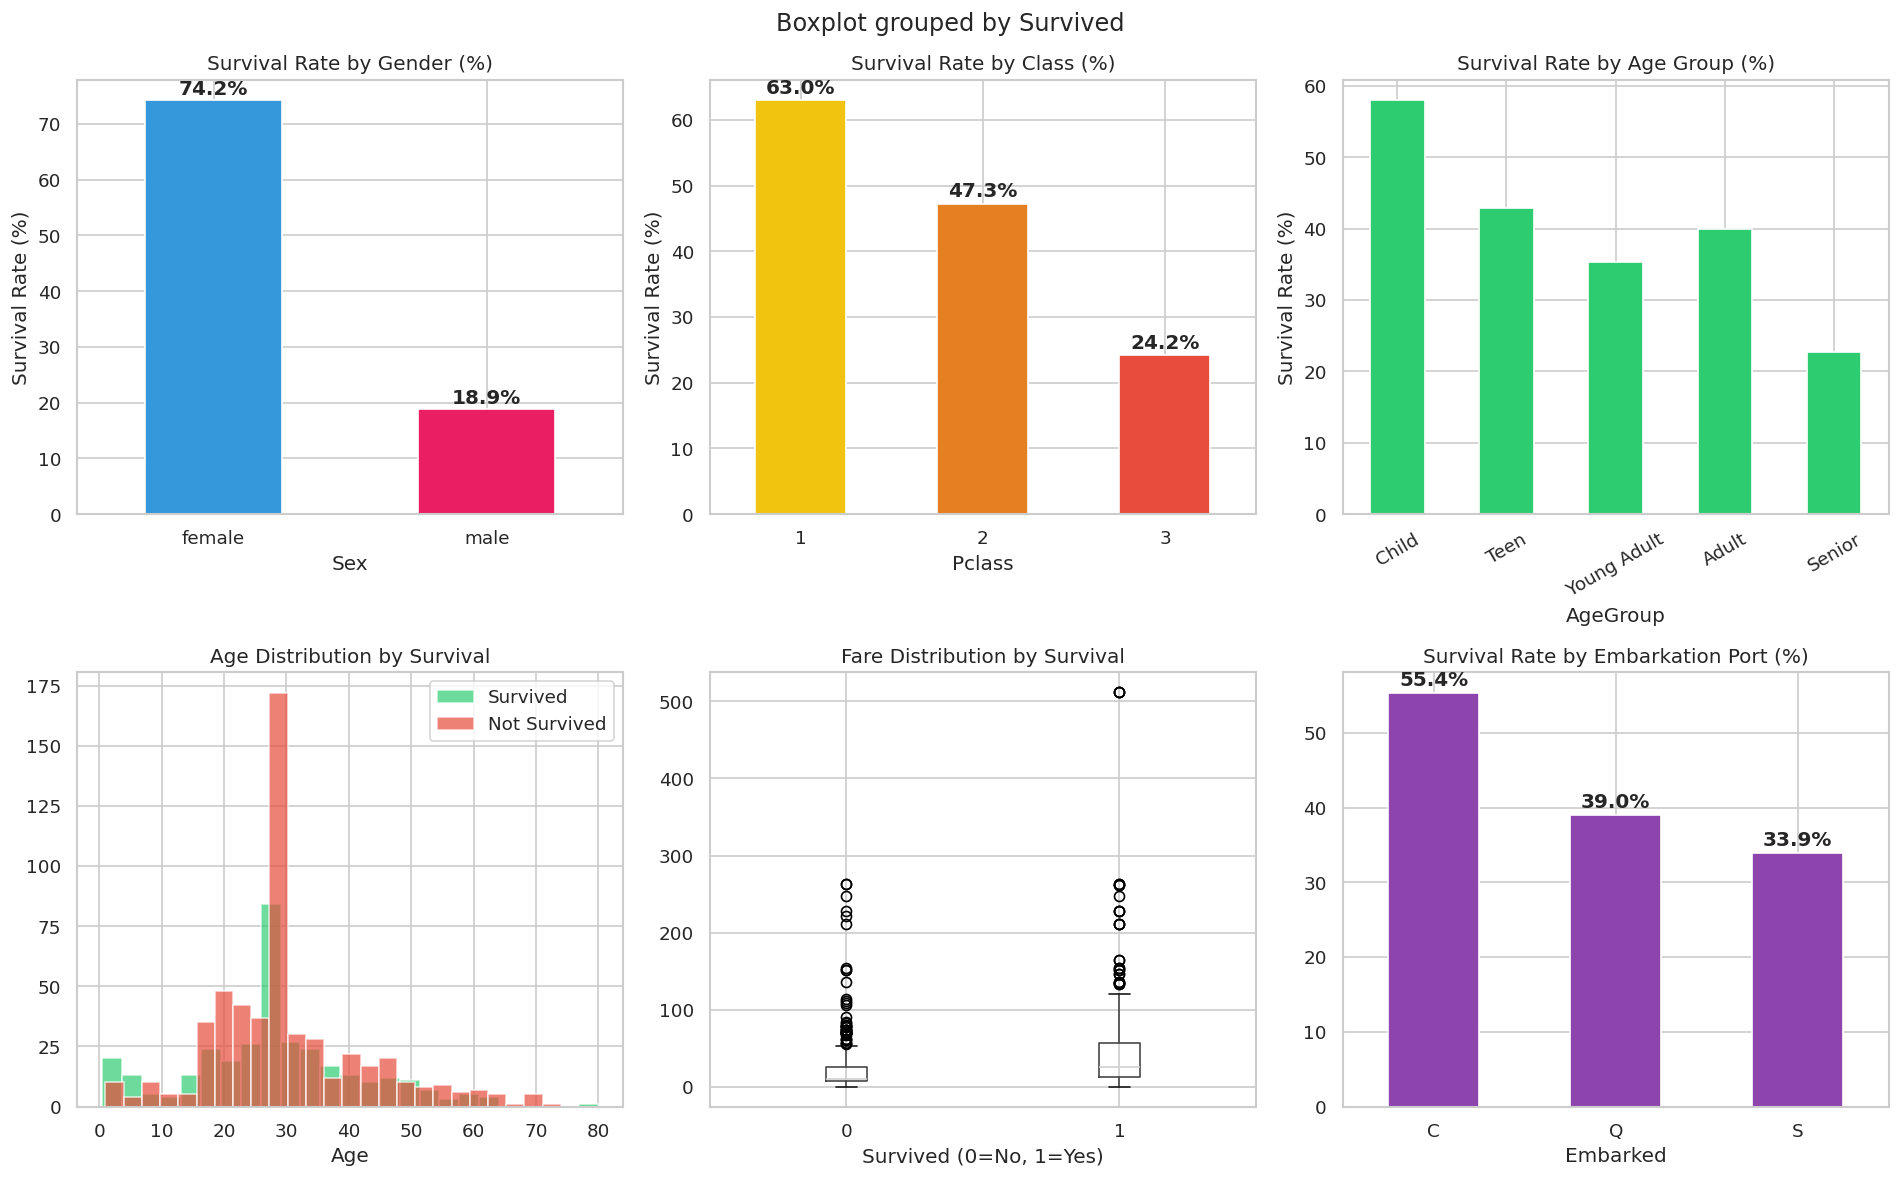

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Bivariate Analysis — Survival vs Variables', fontsize=16, fontweight='bold')

gender_survival = df.groupby('Sex')['Survived'].mean() * 100
gender_survival.plot(kind='bar', ax=axes[0,0], color=['#3498db','#e91e63'], edgecolor='white')
axes[0,0].set_title('Survival Rate by Gender (%)')
axes[0,0].set_ylabel('Survival Rate (%)')
axes[0,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_survival):
    axes[0,0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

class_survival = df.groupby('Pclass')['Survived'].mean() * 100
class_survival.plot(kind='bar', ax=axes[0,1], color=['#f1c40f','#e67e22','#e74c3c'], edgecolor='white')
axes[0,1].set_title('Survival Rate by Class (%)')
axes[0,1].set_ylabel('Survival Rate (%)')
axes[0,1].tick_params(axis='x', rotation=0)
for i, v in enumerate(class_survival):
    axes[0,1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
age_survival.plot(kind='bar', ax=axes[0,2], color='#2ecc71', edgecolor='white')
axes[0,2].set_title('Survival Rate by Age Group (%)')
axes[0,2].set_ylabel('Survival Rate (%)')
axes[0,2].tick_params(axis='x', rotation=30)

df[df['Survived']==1]['Age'].hist(ax=axes[1,0], bins=25, alpha=0.7, label='Survived', color='#2ecc71')
df[df['Survived']==0]['Age'].hist(ax=axes[1,0], bins=25, alpha=0.7, label='Not Survived', color='#e74c3c')
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

df.boxplot(column='Fare', by='Survived', ax=axes[1,1])
axes[1,1].set_title('Fare Distribution by Survival')
axes[1,1].set_xlabel('Survived (0=No, 1=Yes)')
plt.sca(axes[1,1])
plt.title('Fare Distribution by Survival')

embarked_survival = df.groupby('Embarked')['Survived'].mean() * 100
embarked_survival.plot(kind='bar', ax=axes[1,2], color='#8e44ad', edgecolor='white')
axes[1,2].set_title('Survival Rate by Embarkation Port (%)')
axes[1,2].tick_params(axis='x', rotation=0)
for i, v in enumerate(embarked_survival):
    axes[1,2].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('bivariate_analysis.png', bbox_inches='tight')
plt.show()

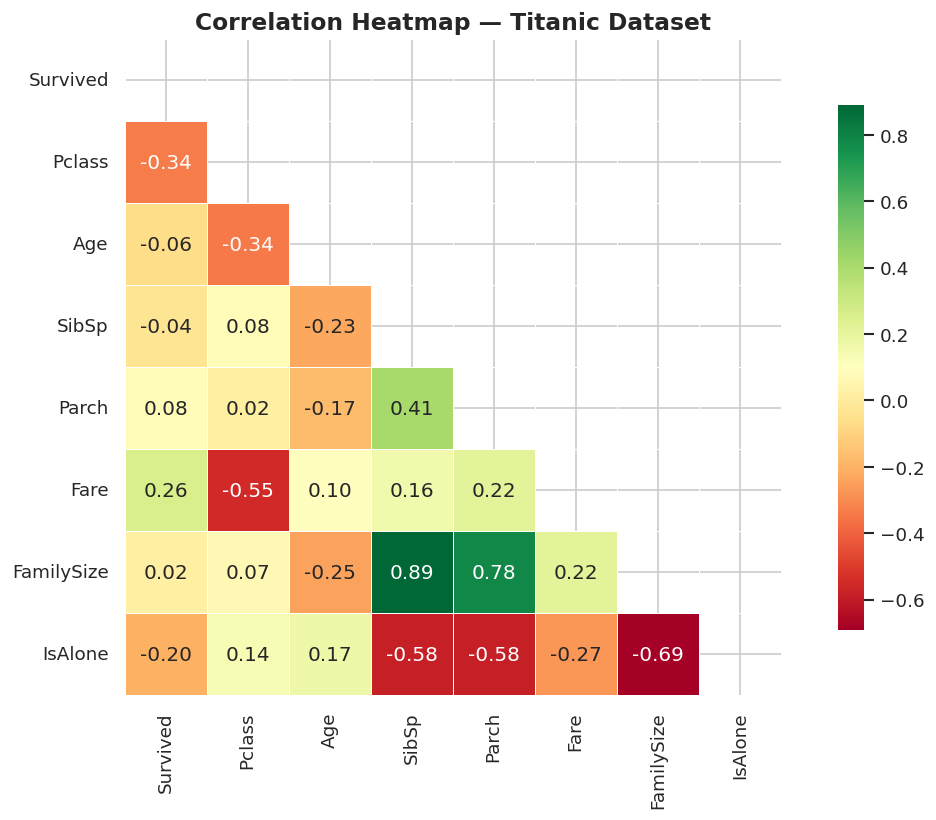

In [25]:
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=['number']).drop(columns=['PassengerId'])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Correlation Heatmap — Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

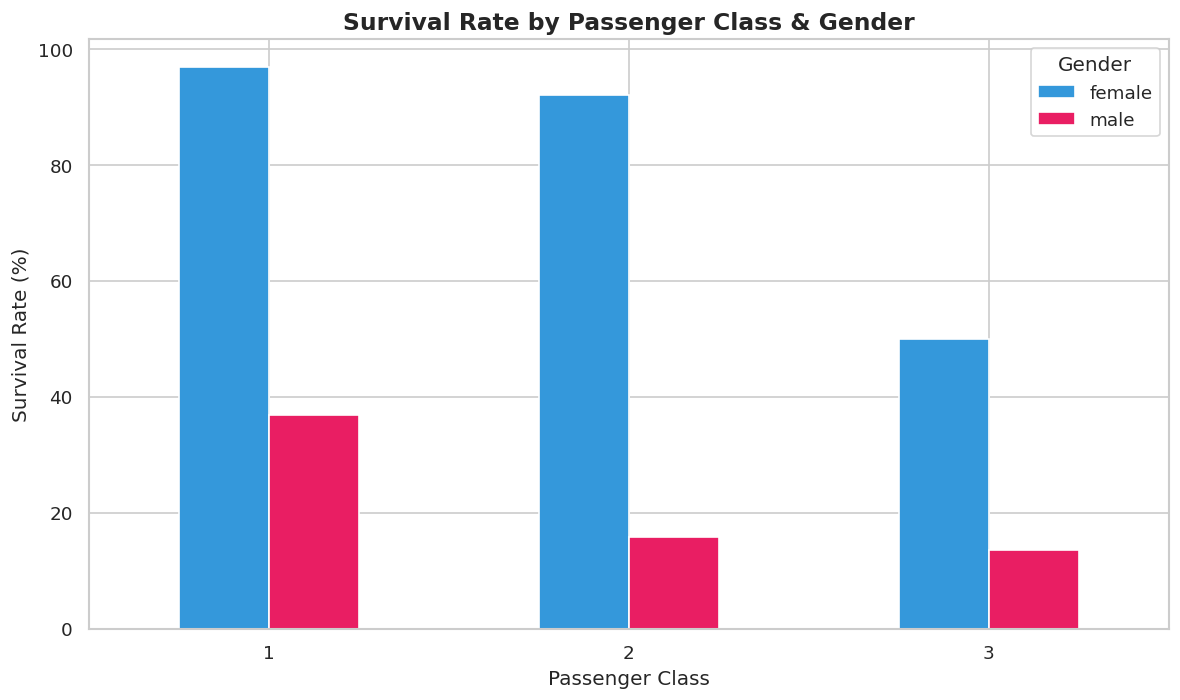

In [26]:
plt.figure(figsize=(10, 6))
pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack() * 100
pivot.plot(kind='bar', ax=plt.gca(), color=['#3498db','#e91e63'], edgecolor='white')
plt.title('Survival Rate by Passenger Class & Gender', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('class_gender_survival.png', bbox_inches='tight')
plt.show()

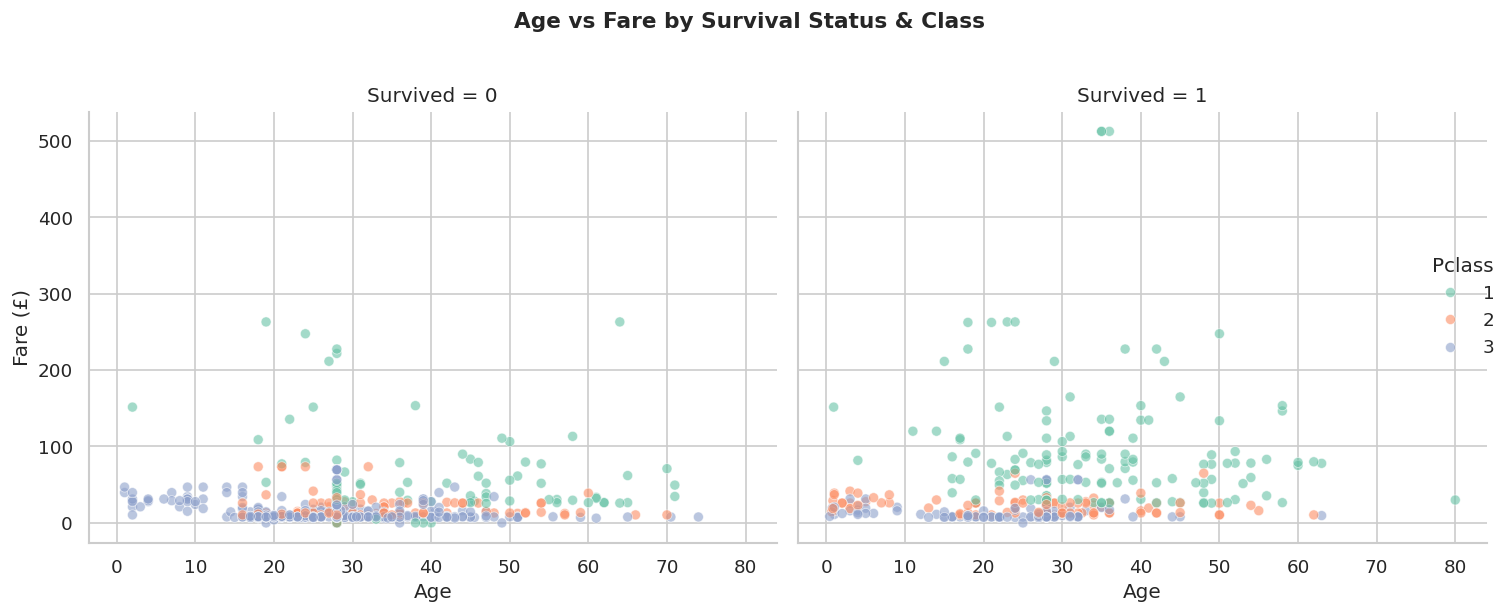

In [27]:
g = sns.FacetGrid(df, col='Survived', height=5, aspect=1.2, palette='Set1')
g.map_dataframe(sns.scatterplot, x='Age', y='Fare', hue='Pclass', alpha=0.6, palette='Set2')
g.add_legend(title='Pclass')
g.set_titles(col_template='Survived = {col_name}')
g.set_axis_labels('Age', 'Fare (£)')
plt.suptitle('Age vs Fare by Survival Status & Class', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('age_fare_survival.png', bbox_inches='tight')
plt.show()

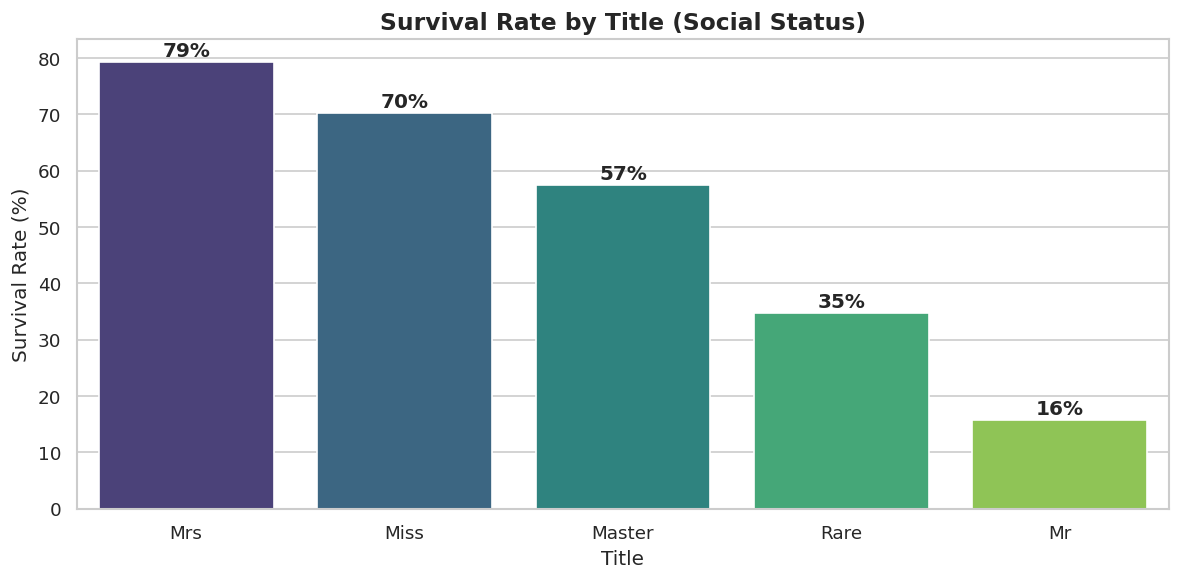

In [28]:
plt.figure(figsize=(10, 5))
title_survival = df.groupby('Title')['Survived'].mean().sort_values(ascending=False) * 100
sns.barplot(x=title_survival.index, y=title_survival.values, palette='viridis')
plt.title('Survival Rate by Title (Social Status)', fontsize=14, fontweight='bold')
plt.xlabel('Title')
plt.ylabel('Survival Rate (%)')
for i, v in enumerate(title_survival.values):
    plt.text(i, v+1, f'{v:.0f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('title_survival.png', bbox_inches='tight')
plt.show()

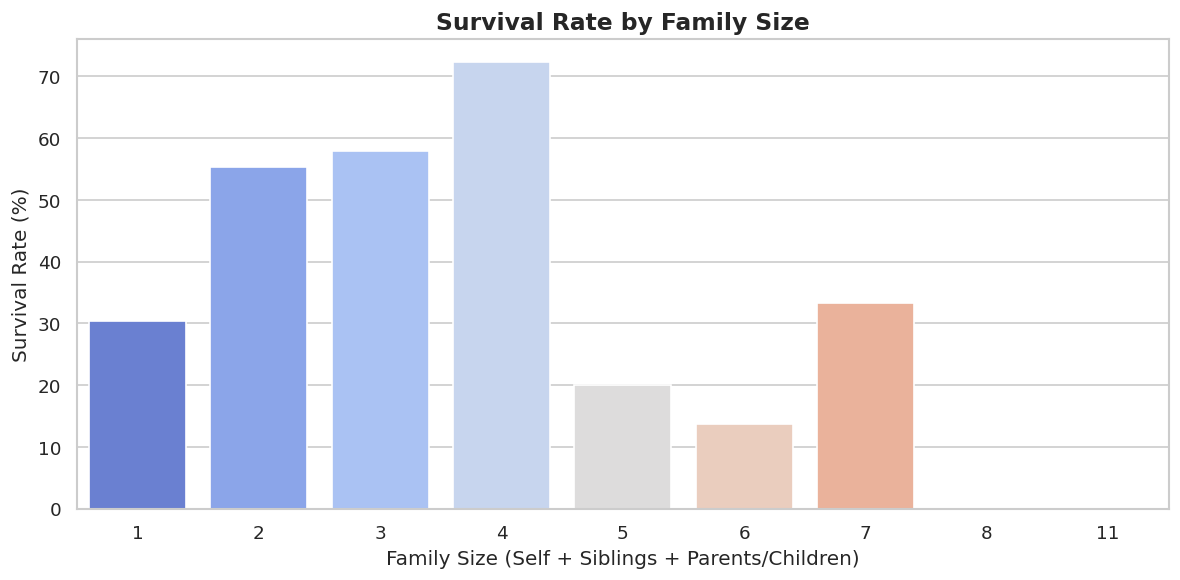

In [29]:
plt.figure(figsize=(10, 5))
family_survival = df.groupby('FamilySize')['Survived'].mean().sort_index() * 100
sns.barplot(x=family_survival.index, y=family_survival.values, palette='coolwarm')
plt.title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
plt.xlabel('Family Size (Self + Siblings + Parents/Children)')
plt.ylabel('Survival Rate (%)')
plt.tight_layout()
plt.savefig('family_survival.png', bbox_inches='tight')
plt.show()

In [30]:
print('KEY INSIGHTS FROM TITANIC EDA')

overall_survival = df['Survived'].mean() * 100
female_survival = df[df['Sex']=='female']['Survived'].mean() * 100
male_survival = df[df['Sex']=='male']['Survived'].mean() * 100
class1_survival = df[df['Pclass']==1]['Survived'].mean() * 100
class3_survival = df[df['Pclass']==3]['Survived'].mean() * 100
child_survival = df[df['AgeGroup']=='Child']['Survived'].mean() * 100

print(f'\n1. Overall Survival Rate       : {overall_survival:.1f}%')
print(f'2. Female Survival Rate        : {female_survival:.1f}%')
print(f'3. Male Survival Rate          : {male_survival:.1f}%')
print(f'4. 1st Class Survival Rate     : {class1_survival:.1f}%')
print(f'5. 3rd Class Survival Rate     : {class3_survival:.1f}%')
print(f'6. Children Survival Rate      : {child_survival:.1f}%')

print('Observations')
print('Women had much higher survival (~74%) vs men (~19%)')
print(' 1st class passengers survived at 2x+ rate vs 3rd class')
print(' Children had higher priority in evacuation')
print(' Higher fare strongly correlates with survival')
print(' Passengers from Cherbourg (C) had highest survival rate')
print(' Solo travelers survived less than small family groups')
print(' "Mrs" and "Miss" titles had much higher survival than "Mr"')


KEY INSIGHTS FROM TITANIC EDA

1. Overall Survival Rate       : 38.4%
2. Female Survival Rate        : 74.2%
3. Male Survival Rate          : 18.9%
4. 1st Class Survival Rate     : 63.0%
5. 3rd Class Survival Rate     : 24.2%
6. Children Survival Rate      : 58.0%
Observations
Women had much higher survival (~74%) vs men (~19%)
 1st class passengers survived at 2x+ rate vs 3rd class
 Children had higher priority in evacuation
 Higher fare strongly correlates with survival
 Passengers from Cherbourg (C) had highest survival rate
 Solo travelers survived less than small family groups
 "Mrs" and "Miss" titles had much higher survival than "Mr"
